# NBA Player Archetype Discovery (2023-24 Season)

**Course:** MSBA 511 - Data Mining for Business Analytics  
**Assignment:** GP2 Modeling  
**Group Members:** Remi Robert, Stephen Perrotta, Enzo de Tomi, Nicholas Allen, and Heath Salas

**Project Focus:** Unsupervised learning using K-Means clustering, hierarchical clustering, PCA visualization, and a KNN-based similar-player lookup.


## 1. Problem Introduction and Data Mining Objective

This project uses the **NBA Stats (1947-Present)** Kaggle dataset, scoped mainly to the **2023-24 NBA regular season**, to identify modern NBA player archetypes from performance data. The original proposal focused on the idea that the traditional five-position system - point guard, shooting guard, small forward, power forward, and center - does not fully capture how players are used in today's NBA.

The main problem is that many players now have hybrid roles. For example, some centers act as playmakers, some guards rebound at a high level, and many forwards combine scoring, defense, and shooting. Because of that, this analysis uses player statistics instead of position labels to see whether more useful groupings can be found.

**Data mining objective:** Use unsupervised learning to group NBA players into natural statistical archetypes based on scoring, playmaking, rebounding, defense, efficiency, and usage metrics. The goal is not to predict a target variable, but to discover meaningful player groups and compare those groups with traditional positions.

**Main techniques used:**
- Data cleaning and feature engineering
- Standard scaling for distance-based modeling
- K-Means clustering as the primary model
- Elbow method and silhouette analysis to evaluate possible values of k
- Hierarchical clustering as a validation method
- PCA for visualization and interpretation
- KNN nearest-neighbor lookup to identify statistically similar players


## 2. Imports and Setup

This section imports the Python libraries used for data cleaning, visualization, clustering, dimensionality reduction, and model evaluation. The modeling workflow relies mostly on `pandas`, `numpy`, `scikit-learn`, `scipy`, `matplotlib`, and `seaborn`.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded.')

Libraries loaded.


## 3. Load Data

The analysis uses two files from the Kaggle NBA dataset: `Player Per Game.csv` and `Advanced.csv`. The per-game file provides traditional box score statistics, while the advanced file adds efficiency and impact metrics such as PER, True Shooting Percentage, Win Shares, BPM, and VORP.

Both files should be placed in the same folder as this notebook before running the code.


In [ ]:
pg = pd.read_csv('Player Per Game.csv')
adv = pd.read_csv('Advanced.csv')

print(f'Per Game: {pg.shape}  |  Advanced: {adv.shape}')

Per Game: (33339, 32)  |  Advanced: (33339, 30)


## 4. Data Cleaning and Merge

This section filters the dataset to the 2023-24 season, handles players who were traded, removes duplicate advanced-stat rows, and merges the per-game and advanced-stat tables.

For traded players, the notebook keeps the `TOT` row when available. This avoids counting the same player multiple times across different teams. After the merge, players with very limited playing time are filtered out using minimum games and minutes thresholds. This keeps the clusters focused on players with a meaningful statistical sample.


In [ ]:
# Filter to 2023-24
pg_24 = pg[pg['season'] == 2024].copy()
adv_24 = adv[adv['season'] == 2024].copy()

# Handle traded players -- keep only the TOT row
def dedupe_traded(df, team_col='team'):
    traded = df[df[team_col] == 'TOT']['player'].unique()
    return df[~((df['player'].isin(traded)) & (df[team_col] != 'TOT'))].copy()

pg_24  = dedupe_traded(pg_24)
adv_24 = dedupe_traded(adv_24)

print(f'After dedup -- Per Game: {len(pg_24)}  |  Advanced: {len(adv_24)}')

# Drop any remaining duplicate player_id rows in Advanced before merging
adv_24 = adv_24.drop_duplicates(subset=['player_id', 'season'])
print(f'Advanced after player_id dedup: {len(adv_24)}')

# Merge
adv_keep = ['player_id', 'season', 'per', 'ts_percent', 'ws', 'bpm', 'vorp']
df = pg_24.merge(adv_24[adv_keep], on=['player_id', 'season'], how='left')

print(f'Merged shape: {df.shape}')
print(f'Advanced cols null count: {df[["per","ts_percent","ws","bpm","vorp"]].isnull().sum().to_dict()}')

# Minutes & games filter
df = df[(df['mp_per_game'] >= 10) & (df['g'] >= 20)].reset_index(drop=True)
print(f'After minutes/games filter: {len(df)} players')

After dedup -- Per Game: 735  |  Advanced: 735
Advanced after player_id dedup: 572
Merged shape: (735, 37)
Advanced cols null count: {'per': 0, 'ts_percent': 4, 'ws': 0, 'bpm': 0, 'vorp': 0}
After minutes/games filter: 485 players


In [ ]:
# Sanity check
df[['player', 'pos', 'team', 'g', 'mp_per_game', 'pts_per_game',
    'x3p_per_game', 'per', 'bpm', 'vorp']].head(10)

,player,pos,team,g,mp_per_game,pts_per_game,x3p_per_game,per,bpm,vorp
0,Precious Achiuwa,PF,2TM,74,21.9,7.6,0.4,14.6,-1.4,0.2
1,Precious Achiuwa,C,TOR,25,17.5,7.7,0.5,14.6,-1.4,0.2
2,Precious Achiuwa,PF,NYK,49,24.2,7.6,0.3,14.6,-1.4,0.2
3,Bam Adebayo,C,MIA,71,34.0,19.3,0.2,19.8,2.4,2.7
4,Ochai Agbaji,SG,2TM,78,21.0,5.8,0.8,7.7,-4.4,-1.0
5,Ochai Agbaji,SG,UTA,51,19.7,5.4,0.9,7.7,-4.4,-1.0
6,Ochai Agbaji,SG,TOR,27,23.6,6.7,0.6,7.7,-4.4,-1.0
7,Santi Aldama,PF,MEM,61,26.5,10.7,1.7,13.1,-0.2,0.7
8,Nickeil Alexander-Walker,SG,MIN,82,23.4,8.0,1.6,10.9,0.2,1.1
9,Grayson Allen,SG,PHO,75,33.5,13.5,2.7,13.8,1.3,2.0


## 5. Feature Selection and Simple Feature Engineering

The selected features represent the major parts of player performance: scoring, shooting efficiency, playmaking, rebounding, defense, advanced impact, and minutes played. These variables were chosen because they describe how a player contributes on the court more directly than traditional position labels.

The feature set also combines traditional statistics with advanced metrics, which helps the clustering model separate high-usage stars, role players, perimeter wings, and interior bigs.


In [ ]:
features = [
    # Scoring
    'pts_per_game',    # Points per game
    'fg_per_game',     # Field goals made
    'x3p_per_game',    # 3-pointers made
    'ft_per_game',     # Free throws made
    'fg_percent',      # FG%
    'x3p_percent',     # 3P%
    'ts_percent',      # True Shooting % (Advanced)
    # Playmaking
    'ast_per_game',    # Assists
    'tov_per_game',    # Turnovers
    # Rebounding
    'orb_per_game',    # Offensive rebounds
    'drb_per_game',    # Defensive rebounds
    'trb_per_game',    # Total rebounds
    # Defense
    'stl_per_game',    # Steals
    'blk_per_game',    # Blocks
    # Advanced
    'per',             # Player Efficiency Rating
    'ws',              # Win Shares
    'bpm',             # Box Plus/Minus
    'vorp',            # Value Over Replacement
    # Usage
    'mp_per_game',     # Minutes per game
]

missing = [f for f in features if f not in df.columns]
if missing:
    print(f'WARNING -- columns not found: {missing}')
else:
    print('All features found!')

features = [f for f in features if f in df.columns]
print(f'Using {len(features)} features.')

All features found!
Using 19 features.


In [ ]:
# Build feature matrix
df_model = df[['player', 'pos', 'team'] + features].dropna(subset=features).copy()
df_model = df_model.reset_index(drop=True)

X_raw = df_model[features].values
print(f'Modeling matrix: {X_raw.shape[0]} players x {X_raw.shape[1]} features')
print(f'Nulls remaining: {np.isnan(X_raw).sum()}')

Modeling matrix: 469 players x 19 features
Nulls remaining: 0


**Cleaning result:** After filtering, merging, and removing rows with missing model features, the final 2023-24 modeling dataset contains **469 players** across **19 numeric features**. Dropping incomplete rows is appropriate here because the clustering algorithms require a complete numeric feature matrix.


## 6. Preprocessing Pipeline: Scaling

K-Means, hierarchical clustering, PCA, and KNN all depend on distance calculations. Because the features are on different scales - for example, points per game, shooting percentages, and VORP - the data is standardized before modeling.

`StandardScaler` transforms each feature to have an average near 0 and a standard deviation near 1. This prevents high-volume statistics from dominating the clustering only because they have larger numeric ranges.


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print('Means after scaling (should be ~0):')
print(pd.Series(np.round(X.mean(axis=0), 3), index=features).to_string())
print('\nStds after scaling (should be ~1):')
print(pd.Series(np.round(X.std(axis=0), 3), index=features).to_string())

Means after scaling (should be ~0):
pts_per_game   -0.0
fg_per_game    -0.0
x3p_per_game   -0.0
ft_per_game     0.0
fg_percent     -0.0
x3p_percent    -0.0
ts_percent     -0.0
ast_per_game   -0.0
tov_per_game    0.0
orb_per_game   -0.0
drb_per_game    0.0
trb_per_game   -0.0
stl_per_game    0.0
blk_per_game    0.0
per             0.0
ws              0.0
bpm            -0.0
vorp            0.0
mp_per_game    -0.0

Stds after scaling (should be ~1):
pts_per_game    1.0
fg_per_game     1.0
x3p_per_game    1.0
ft_per_game     1.0
fg_percent      1.0
x3p_percent     1.0
ts_percent      1.0
ast_per_game    1.0
tov_per_game    1.0
orb_per_game    1.0
drb_per_game    1.0
trb_per_game    1.0
stl_per_game    1.0
blk_per_game    1.0
per             1.0
ws              1.0
bpm             1.0
vorp            1.0
mp_per_game     1.0


## 7. Model Selection: Elbow Method and Silhouette Analysis

This section evaluates different values of `k`, which is the number of clusters used by K-Means.

- The **elbow method** shows how within-cluster error changes as k increases.
- The **silhouette score** measures how well-separated the clusters are.

Although the highest silhouette score may favor fewer clusters, the final model uses **k = 4** because four groups provide a more useful and interpretable set of NBA player archetypes for the business problem.


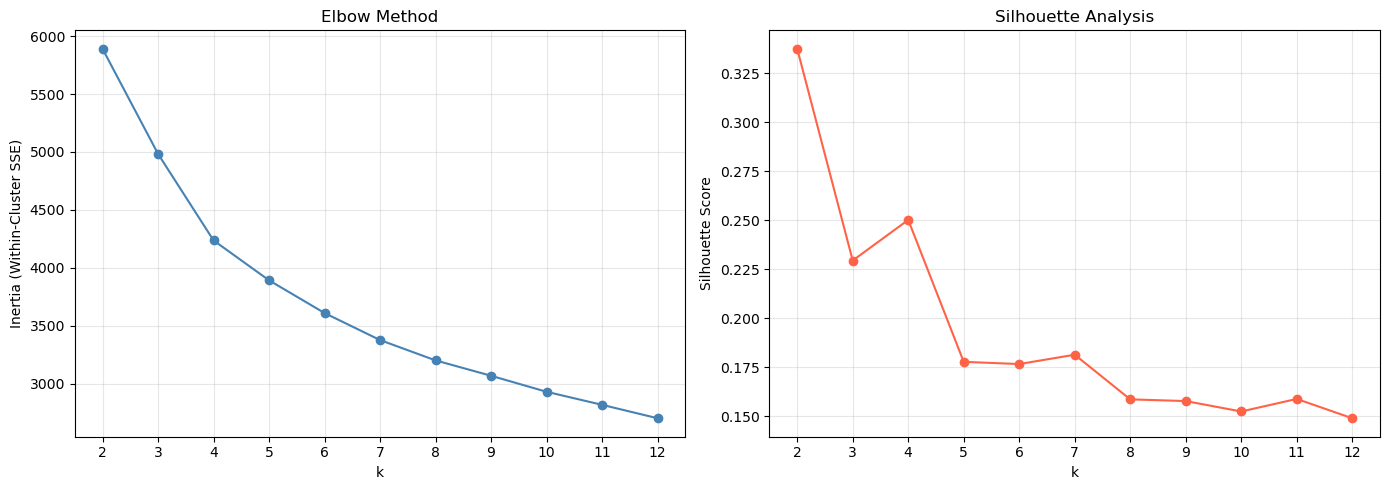

Best k by silhouette: 2  (score = 0.337)
Check the elbow plot and override K_FINAL in Section 7 if needed.


In [ ]:
k_range = range(2, 13)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'o-', color='tomato')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Best k by silhouette: {best_k}  (score = {max(sil_scores):.3f})')
print('Check the elbow plot and override K_FINAL in Section 7 if needed.')

**Model selection note:** The silhouette score is useful, but it should not be the only deciding factor. The final choice of **4 clusters** gives a clearer basketball interpretation than a smaller number of groups, while still keeping the model simple enough to explain.


## 8. Final K-Means Model and Silhouette Detail

K-Means is the primary clustering technique for this project. It groups players by similarity across the standardized feature set. The final model uses **4 clusters**, which balances statistical evaluation with interpretability.

The silhouette plot helps check whether the clusters are reasonably separated. Players with stronger silhouette values are more clearly assigned to their cluster, while values closer to zero indicate players who sit between multiple archetypes.


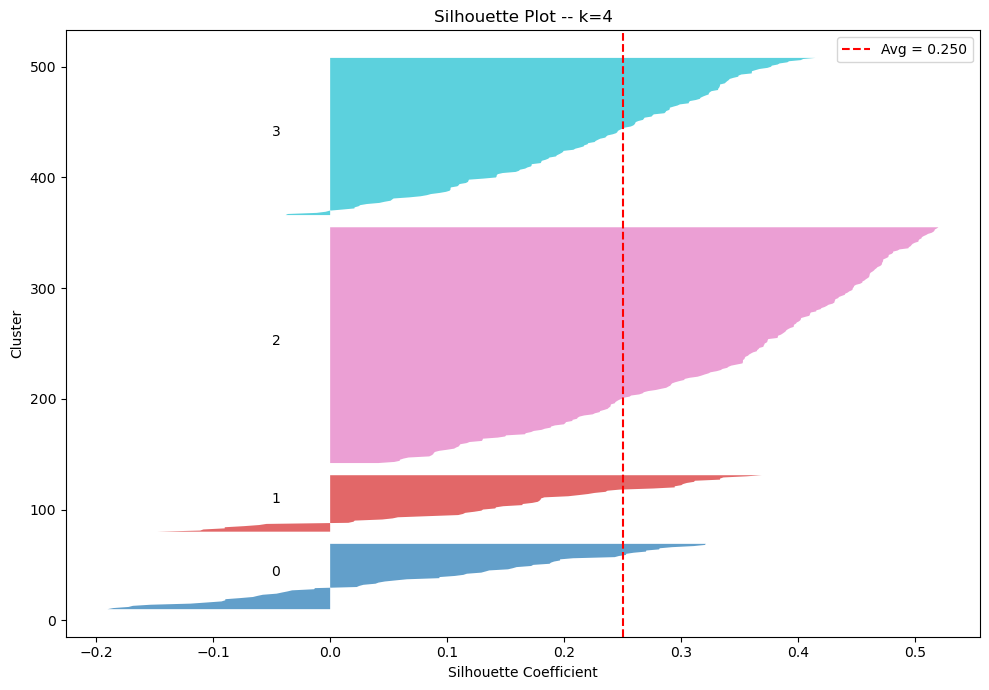

In [ ]:
# Set k here -- defaults to best silhouette score; uncomment override if preferred
#K_FINAL = best_k
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
labels_final = km_final.fit_predict(X)
colors = cm.tab10(np.linspace(0, 1, K_FINAL))

sil_vals = silhouette_samples(X, labels_final)
avg_sil  = silhouette_score(X, labels_final)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for i in range(K_FINAL):
    cluster_sil = sorted(sil_vals[labels_final == i])
    y_upper = y_lower + len(cluster_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + len(cluster_sil) / 2, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg = {avg_sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot -- k={K_FINAL}')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_detail.png', bbox_inches='tight')
plt.show()

## 9. Cluster Profiles

After clustering, the notebook profiles each group using the original, unscaled statistics. This step is important because standardized model values are useful for training, but original-scale averages are easier to interpret.

The profiles show how each cluster differs in scoring, assists, rebounds, blocks, shooting, efficiency, and advanced impact. These summaries are used later to assign basketball-style archetype names to the clusters.


In [ ]:
df_model['cluster'] = labels_final

print('Players per cluster:')
print(df_model['cluster'].value_counts().sort_index())
print('\nPosition breakdown per cluster:')
print(pd.crosstab(df_model['cluster'], df_model['pos']))

Players per cluster:
cluster
0     60
1     52
2    214
3    143
Name: count, dtype: int64

Position breakdown per cluster:
pos       C  PF  PG  SF  SG
cluster                    
0        44  13   0   3   0
1        10  15  14   5   8
2        13  44  50  51  56
3         2  25  33  42  41


In [ ]:
key_cols = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3p_per_game', 'ts_percent', 'per', 'bpm', 'vorp']
key_cols = [c for c in key_cols if c in df_model.columns]

print('Cluster Profiles (original scale averages):')
display(df_model.groupby('cluster')[key_cols].mean().round(2))

Cluster Profiles (original scale averages):


,pts_per_game,ast_per_game,trb_per_game,blk_per_game,stl_per_game,x3p_per_game,ts_percent,per,bpm,vorp
cluster,,,,,,,,,,
0,9.22,1.59,6.43,0.85,0.61,0.38,0.63,17.42,0.40,0.88
1,23.46,5.60,6.55,0.78,1.14,2.07,0.60,21.35,4.12,3.59
2,5.84,1.54,2.48,0.29,0.56,0.87,0.54,10.83,-2.39,-0.04
3,13.82,3.39,4.22,0.41,0.87,1.89,0.57,13.77,-0.69,0.63


**Cluster interpretation:** The original-scale profiles show four clear player types: a high-impact star group, an interior big group, a lower-volume role-player group, and a perimeter-oriented wing/guard group. These profiles are the basis for the final archetype labels.


In [ ]:
# Top players per cluster
for c in sorted(df_model['cluster'].unique()):
    sample = (df_model[df_model['cluster'] == c]
              .sort_values('pts_per_game', ascending=False)
              [['player', 'pos', 'team', 'pts_per_game', 'ast_per_game',
                'trb_per_game', 'blk_per_game', 'x3p_per_game']]
              .head(5))
    print(f'\n--- Cluster {c} ---')
    display(sample)


--- Cluster 0 ---


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game
427,Nikola Vučević,C,CHI,18.0,3.3,10.5,0.8,1.2
420,Myles Turner,C,IND,17.1,1.3,6.9,1.9,1.5
19,Deandre Ayton,C,POR,16.7,1.6,11.1,0.8,0.0
10,Jarrett Allen,C,CLE,16.5,2.7,10.5,1.1,0.0
294,Evan Mobley,PF,CLE,15.7,3.2,9.4,1.4,0.4



--- Cluster 1 ---


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game
129,Joel Embiid,C,PHI,34.7,5.6,11.0,1.7,1.4
118,Luka Dončić,PG,DAL,33.9,9.8,9.2,0.5,4.1
13,Giannis Antetokounmpo,PF,MIL,30.4,6.5,11.5,1.1,0.5
152,Shai Gilgeous-Alexander,PG,OKC,30.1,6.2,5.5,0.9,1.3
75,Jalen Brunson,PG,NYK,28.7,6.7,3.6,0.2,2.7



--- Cluster 2 ---


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game
78,Alec Burks,SG,DET,12.6,1.6,2.6,0.3,2.3
77,Alec Burks,SG,2TM,10.4,1.3,2.3,0.2,1.9
56,Bojan Bogdanović,SF,NYK,10.4,0.9,2.0,0.0,1.6
28,Dalano Banton,PG,2TM,10.3,2.4,3.3,0.4,1.1
213,Reggie Jackson,PG,DEN,10.2,3.8,1.9,0.2,1.2



--- Cluster 3 ---


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game
104,Cade Cunningham,PG,DET,22.7,7.5,4.3,0.4,1.9
384,Anfernee Simons,SG,POR,22.6,5.5,3.6,0.1,3.4
405,Cam Thomas,SG,BRK,22.5,2.9,3.2,0.2,2.2
238,Kyle Kuzma,PF,WAS,22.2,4.2,6.6,0.7,2.2
35,RJ Barrett,SG,TOR,21.8,4.1,6.4,0.4,1.5


## 10. Cluster Heatmap

The heatmap displays standardized centroid values for each cluster. Positive values mean the cluster is above the league sample average for that feature, while negative values mean it is below average.

This visual helps identify what makes each cluster unique. For example, a cluster with high rebounding and blocks but low three-point volume is likely an interior big archetype, while a cluster with high scoring, assists, and advanced metrics is likely an elite star archetype.


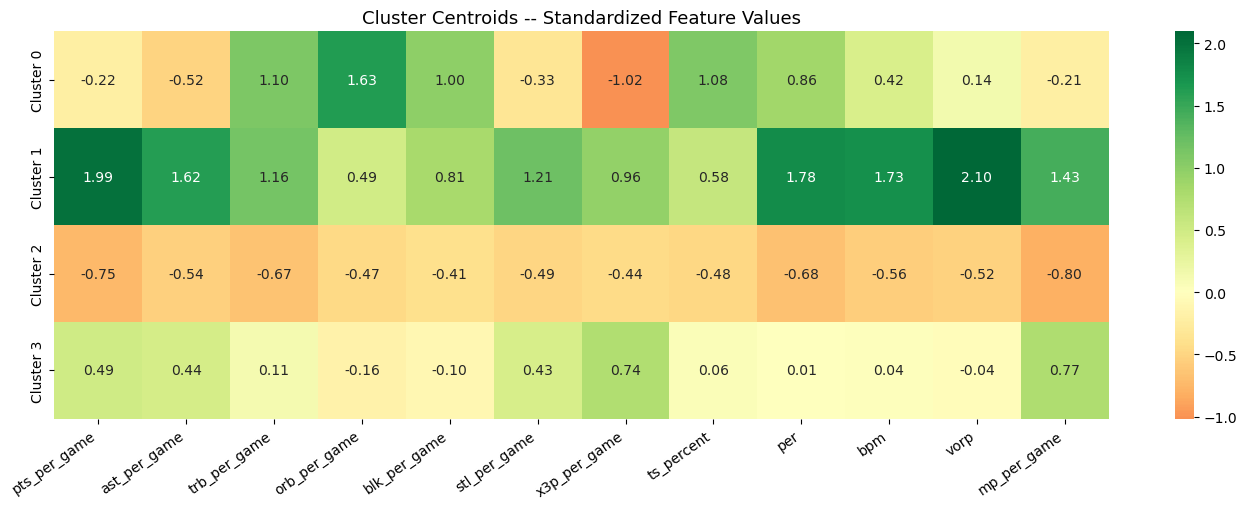

In [ ]:
centroids_df = pd.DataFrame(km_final.cluster_centers_, columns=features)

hm_cols = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'orb_per_game',
           'blk_per_game', 'stl_per_game', 'x3p_per_game', 'ts_percent',
           'per', 'bpm', 'vorp', 'mp_per_game']
hm_cols = [c for c in hm_cols if c in features]

fig, ax = plt.subplots(figsize=(14, K_FINAL * 0.8 + 2))
sns.heatmap(centroids_df[hm_cols], annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax,
            yticklabels=[f'Cluster {i}' for i in range(K_FINAL)])
ax.set_title('Cluster Centroids -- Standardized Feature Values', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', bbox_inches='tight')
plt.show()

## 11. PCA Visualization

PCA reduces the high-dimensional feature set into fewer components so the clusters can be visualized in two dimensions. This does not replace the clustering model; it is mainly used to make the patterns easier to see.

The PCA plots help show whether the K-Means clusters form visible groups and which features are most responsible for separating players. The first two principal components explain a large share of the variation, while additional components are needed to capture the remaining structure.


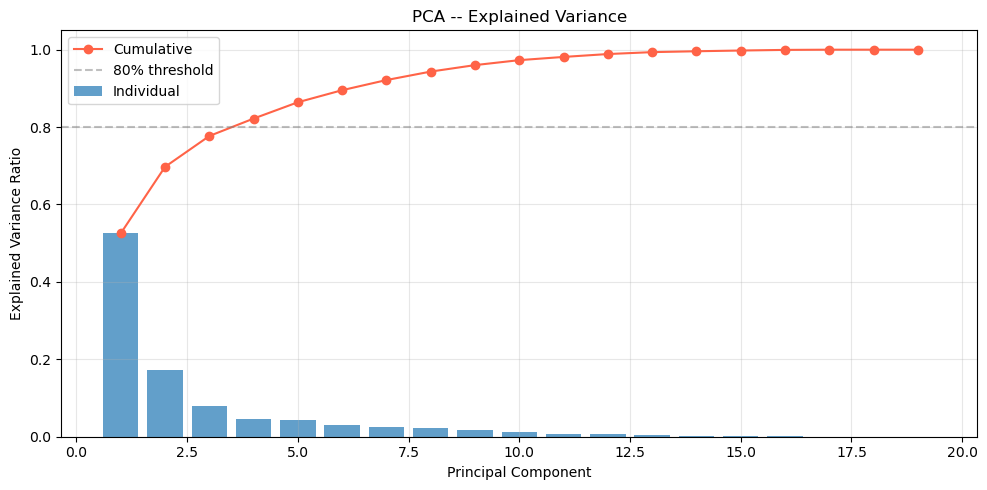

PC1 + PC2: 69.7% of variance
Components for 80%: 4


In [ ]:
pca = PCA(random_state=42)
X_pca = pca.fit_transform(X)
explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(explained)+1), explained, alpha=0.7, label='Individual')
ax.plot(range(1, len(explained)+1), cumulative, 'o-', color='tomato', label='Cumulative')
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA -- Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight')
plt.show()

print(f'PC1 + PC2: {(explained[0]+explained[1])*100:.1f}% of variance')
print(f'Components for 80%: {np.argmax(cumulative >= 0.8) + 1}')

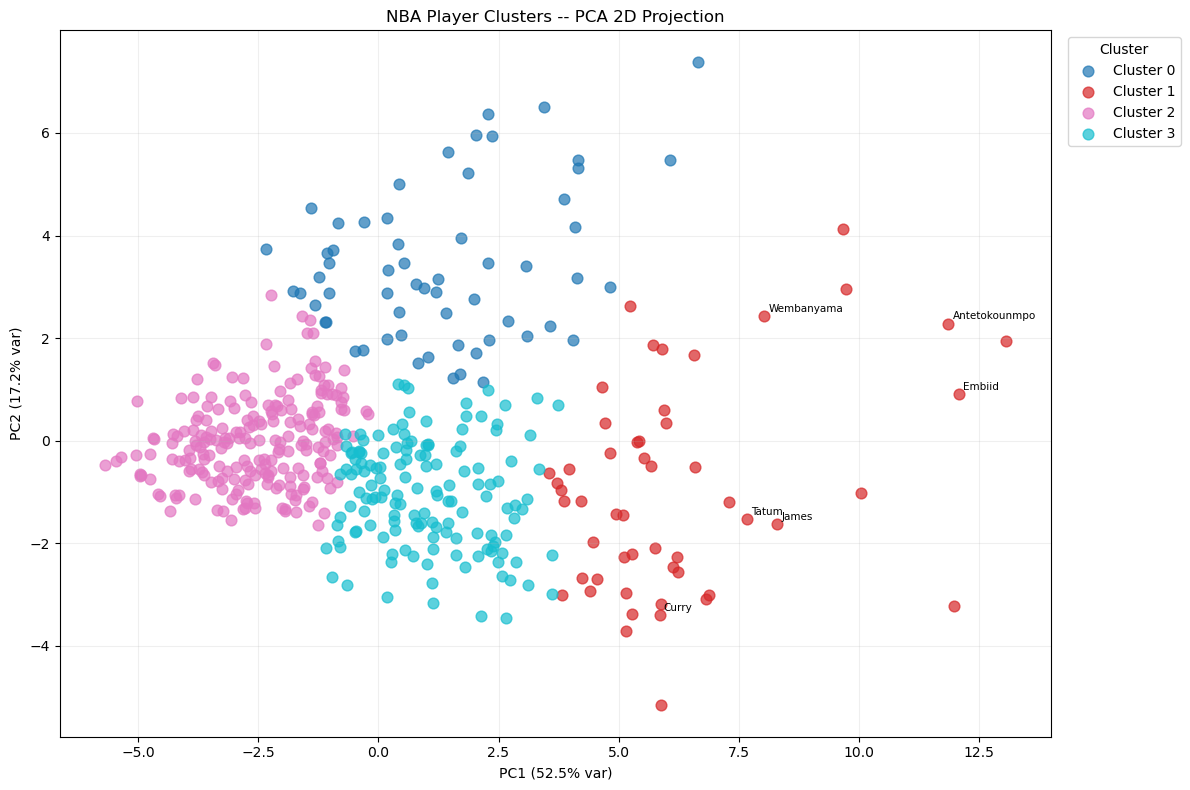

In [ ]:
df_model['pc1'] = X_pca[:, 0]
df_model['pc2'] = X_pca[:, 1]

notable = ['Nikola Jokic', 'LeBron James', 'Stephen Curry', 'Victor Wembanyama',
           'Giannis Antetokounmpo', 'Joel Embiid', 'Luka Doncic', 'Jayson Tatum']

fig, ax = plt.subplots(figsize=(12, 8))
for c in range(K_FINAL):
    mask = df_model['cluster'] == c
    ax.scatter(df_model.loc[mask, 'pc1'], df_model.loc[mask, 'pc2'],
               color=colors[c], label=f'Cluster {c}', alpha=0.7, s=60)

for _, row in df_model[df_model['player'].isin(notable)].iterrows():
    ax.annotate(row['player'].split()[-1], (row['pc1'], row['pc2']),
                fontsize=7.5, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('NBA Player Clusters -- PCA 2D Projection')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

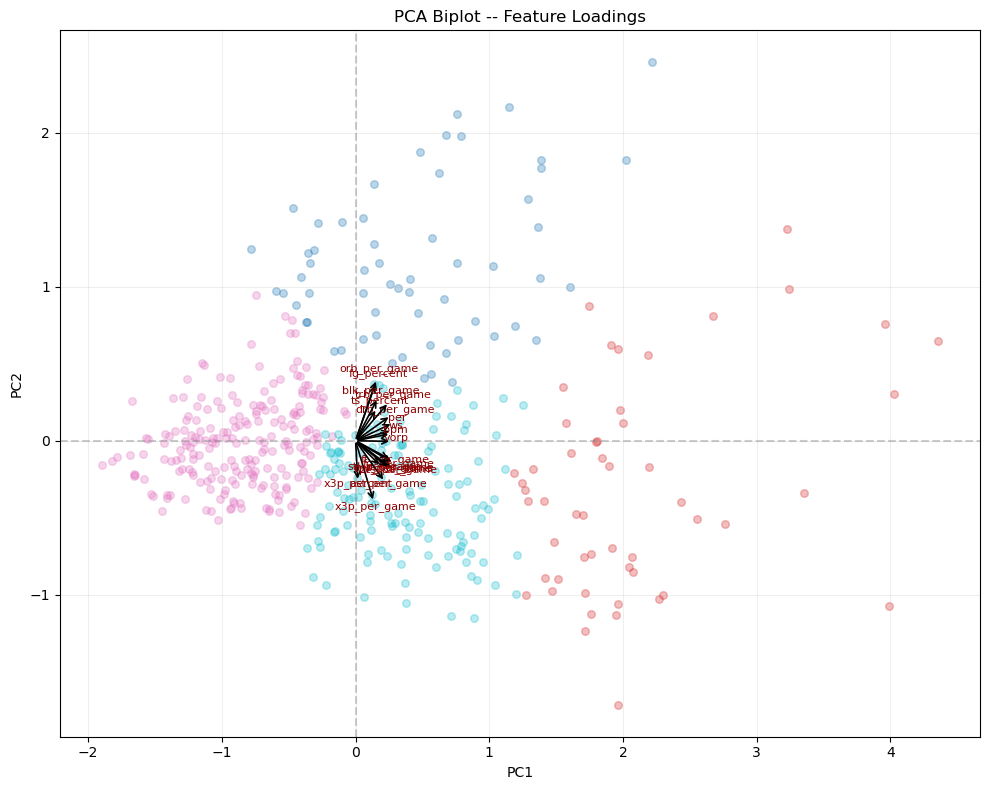

In [ ]:
# Biplot -- feature loadings
loadings = pca.components_.T
scale = 3

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(K_FINAL):
    mask = df_model['cluster'] == c
    ax.scatter(df_model.loc[mask, 'pc1'] / scale,
               df_model.loc[mask, 'pc2'] / scale,
               color=colors[c], alpha=0.3, s=30)

for i, feat in enumerate(features):
    ax.annotate('', xy=(loadings[i,0], loadings[i,1]), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
    ax.text(loadings[i,0]*1.12, loadings[i,1]*1.12,
            feat, fontsize=8, ha='center', color='darkred')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA Biplot -- Feature Loadings')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('pca_biplot.png', bbox_inches='tight')
plt.show()

## 12. Hierarchical Clustering Validation

Hierarchical clustering is used as a secondary method to validate the K-Means results. Ward linkage groups players by minimizing within-cluster variation, which makes it a useful comparison against K-Means.

The Adjusted Rand Index compares the K-Means labels with the hierarchical clustering labels. A higher score means the two methods found more similar groupings. This gives another way to evaluate whether the clusters are stable and meaningful.


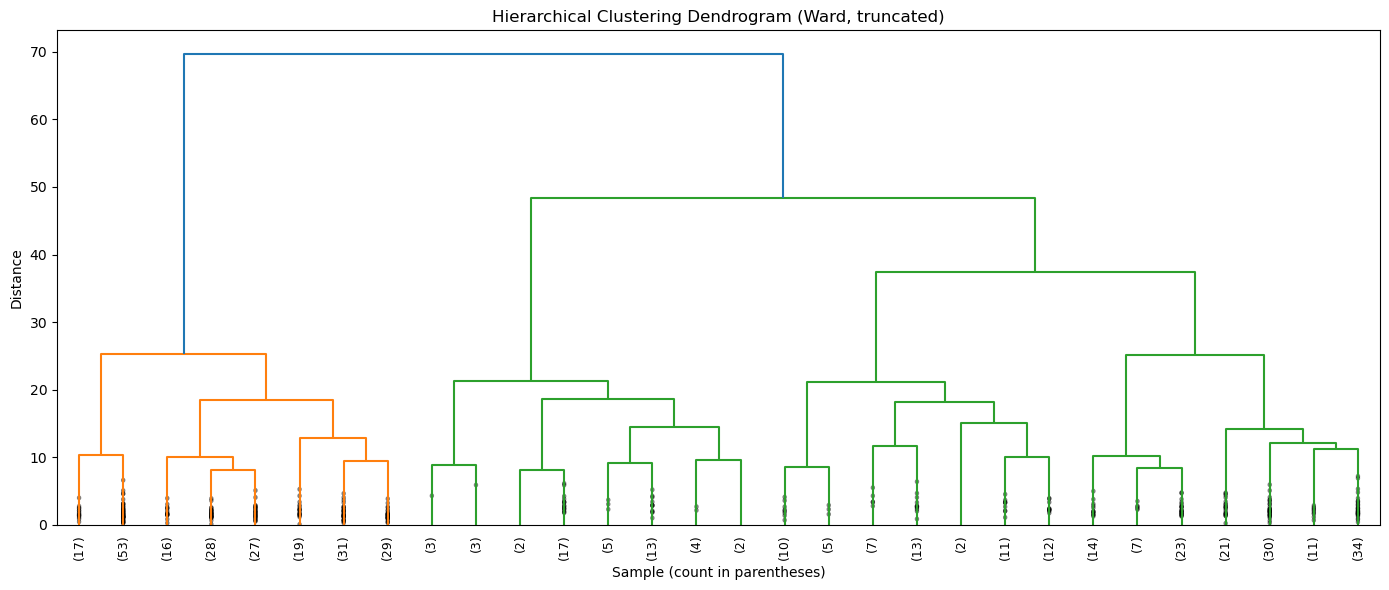

In [ ]:
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward, truncated)')
ax.set_xlabel('Sample (count in parentheses)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()

In [ ]:
hclust_labels = fcluster(Z, t=K_FINAL, criterion='maxclust') - 1
df_model['cluster_hclust'] = hclust_labels

ari = adjusted_rand_score(df_model['cluster'], hclust_labels)
print(f'Adjusted Rand Index (K-Means vs Hierarchical): {ari:.3f}')
print('1.0 = perfect agreement  |  0.0 = random')
print('\nCross-tab:')
print(pd.crosstab(df_model['cluster'], hclust_labels,
                  rownames=['KMeans'], colnames=['HClust']))

Adjusted Rand Index (K-Means vs Hierarchical): 0.583
1.0 = perfect agreement  |  0.0 = random

Cross-tab:
HClust    0   1   2    3
KMeans                  
0         5   4  47    4
1         0  45   0    7
2       190   0   1   23
3        25   0  12  106


**Validation interpretation:** The Adjusted Rand Index of **0.583** shows moderate agreement between K-Means and hierarchical clustering. The methods do not match perfectly, but they identify enough similar structure to support the usefulness of the K-Means solution.


## 13. KNN Similar Player Lookup

KNN is used here as a similarity tool, not as the primary clustering model. After players are represented in the same standardized feature space, nearest neighbors can identify players with similar statistical profiles.

This makes the clustering results more practical: instead of only assigning a player to an archetype, the notebook can also show comparable players based on the same performance variables.


In [ ]:
knn = NearestNeighbors(n_neighbors=6, metric='euclidean').fit(X)

def find_similar_players(player_name):
    if player_name not in df_model['player'].values:
        print(f"'{player_name}' not found -- check spelling or minutes threshold.")
        return
    idx = df_model[df_model['player'] == player_name].index[0]
    dists, idxs = knn.kneighbors(X[idx].reshape(1, -1))
    result = df_model.iloc[idxs[0][1:]][
        ['player', 'pos', 'team', 'pts_per_game', 'ast_per_game',
         'trb_per_game', 'blk_per_game', 'x3p_per_game', 'cluster']
    ].copy()
    result['distance'] = dists[0][1:]
    print(f"\n{player_name} | Pos: {df_model.loc[idx,'pos']} | Cluster: {df_model.loc[idx,'cluster']}")
    display(result)

find_similar_players('Nikola Jokić')
find_similar_players('Stephen Curry')
find_similar_players('Victor Wembanyama')


Nikola Jokić | Pos: C | Cluster: 1


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game,cluster,distance
13,Giannis Antetokounmpo,PF,MIL,30.4,6.5,11.5,1.1,0.5,1,4.318358
368,Domantas Sabonis,C,SAC,19.4,8.2,13.7,0.6,0.4,1,5.513730
118,Luka Dončić,PG,DAL,33.9,9.8,9.2,0.5,4.1,1,6.448857
152,Shai Gilgeous-Alexander,PG,OKC,30.1,6.2,5.5,0.9,1.3,1,6.830855
215,LeBron James,PF,LAL,25.7,8.3,7.3,0.5,2.1,1,7.289430



Stephen Curry | Pos: PG | Cluster: 1


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game,cluster,distance
267,Tyrese Maxey,PG,PHI,25.9,6.2,3.7,0.5,3.0,1,3.274430
206,Kyrie Irving,SG,DAL,25.6,5.2,5.0,0.5,3.0,1,3.313511
271,CJ McCollum,PG,NOP,20.0,4.6,4.3,0.6,3.6,3,3.411307
149,Paul George,PF,LAC,22.6,3.5,5.2,0.5,3.3,1,3.513661
27,Desmond Bane,SG,MEM,23.7,5.5,4.4,0.5,3.3,1,3.535625



Victor Wembanyama | Pos: C | Cluster: 1


,player,pos,team,pts_per_game,ast_per_game,trb_per_game,blk_per_game,x3p_per_game,cluster,distance
196,Chet Holmgren,C,OKC,16.5,2.4,7.9,2.3,1.6,1,5.964207
32,Scottie Barnes,SG,TOR,19.9,6.1,8.2,1.5,1.7,1,5.987929
109,Anthony Davis,C,LAL,24.7,3.5,12.6,2.3,0.4,1,6.037950
341,Kristaps Porziņģis,C,BOS,20.1,2.0,7.2,1.9,1.9,1,6.419998
420,Myles Turner,C,IND,17.1,1.3,6.9,1.9,1.5,0,7.097778


## 14. Archetype Labeling and Interpretation

The cluster names are assigned after reviewing the centroid heatmap, original-scale cluster profiles, and example players in each group. These labels make the model results easier to explain in basketball terms.

The final four archetypes are:
- **Paint Big** - interior players with stronger rebounding, blocks, and efficiency near the rim
- **Elite Star** - high-impact players with strong scoring, playmaking, and advanced metrics
- **Bench / Limited Role Player** - lower-volume players with smaller statistical profiles
- **Perimeter Wing / 3-and-D** - guards/wings/forwards with shooting and balanced perimeter production


In [ ]:
# UPDATE THESE based on your cluster profiles
archetype_labels = {
    0: 'Paint Big',
    1: 'Elite Star',
    2: 'Bench / Limited Role Player',
    3: 'Perimeter Wing / 3-and-D',
}
archetype_labels = {k: v for k, v in archetype_labels.items() if k < K_FINAL}

df_model['archetype'] = df_model['cluster'].map(archetype_labels)
print(df_model['archetype'].value_counts())

archetype
Bench / Limited Role Player    214
Perimeter Wing / 3-and-D       143
Paint Big                       60
Elite Star                      52
Name: count, dtype: int64


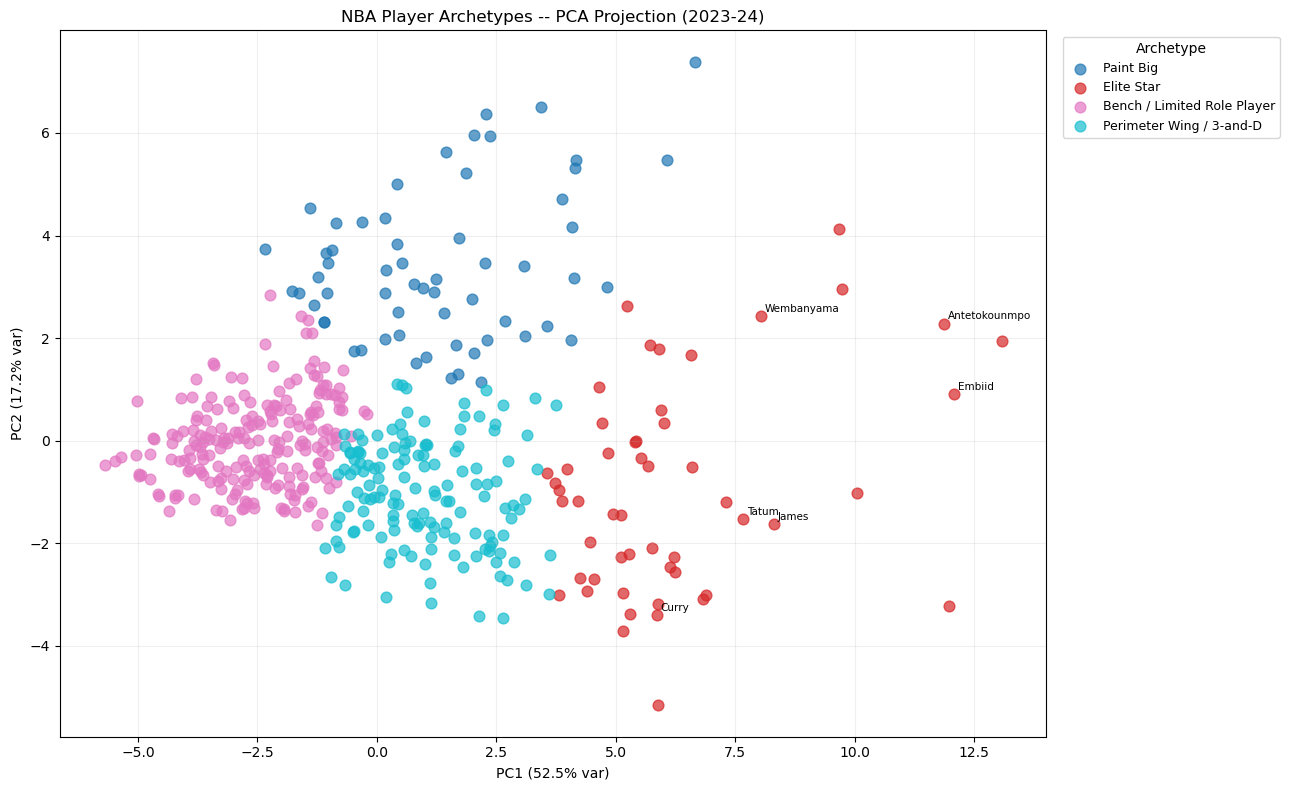

In [ ]:
fig, ax = plt.subplots(figsize=(13, 8))
for c in range(K_FINAL):
    mask = df_model['cluster'] == c
    ax.scatter(df_model.loc[mask, 'pc1'], df_model.loc[mask, 'pc2'],
               color=colors[c], label=archetype_labels.get(c, f'Cluster {c}'),
               alpha=0.7, s=60)

for _, row in df_model[df_model['player'].isin(notable)].iterrows():
    ax.annotate(row['player'].split()[-1], (row['pc1'], row['pc2']),
                fontsize=7.5, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('NBA Player Archetypes -- PCA Projection (2023-24)')
ax.legend(title='Archetype', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('archetypes_final.png', bbox_inches='tight')
plt.show()

## 15. Export Results

This section exports the final player-level archetype assignments to a CSV file. The output includes player identity fields, cluster labels, archetype names, key statistics, and PCA coordinates.

This exported file can be used for additional reporting, dashboarding, or team-level analysis.


In [ ]:
out_cols = ['player', 'pos', 'team', 'cluster', 'archetype',
            'pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game',
            'stl_per_game', 'x3p_per_game', 'ts_percent', 'per', 'bpm', 'vorp',
            'mp_per_game', 'pc1', 'pc2']
out_cols = [c for c in out_cols if c in df_model.columns]

df_out = df_model[out_cols].sort_values(['cluster', 'pts_per_game'], ascending=[True, False])
df_out.to_csv('nba_player_archetypes_2024.csv', index=False)
print(f'Saved nba_player_archetypes_2024.csv  ({len(df_out)} players)')
display(df_out.head(10))

## 16. Main Analysis Summary and Evaluation

| Requirement Area | What This Notebook Includes |
|---|---|
| Problem introduction | Explains why modern NBA roles may be better described by data-driven archetypes than traditional positions |
| Data cleaning | Filters to 2023-24, handles traded-player duplicates, removes duplicate advanced-stat rows, merges per-game and advanced data, filters low-minute players, and drops rows with missing model features |
| Feature engineering / selection | Uses scoring, shooting, playmaking, rebounding, defense, advanced impact, and usage-related metrics |
| Pipeline / modeling | Standard scaling followed by K-Means clustering, hierarchical clustering, PCA visualization, and KNN similarity lookup |
| Evaluation | Uses elbow method, silhouette analysis, cluster profiles, PCA plots, and Adjusted Rand Index comparison with hierarchical clustering |
| Interpretation | Assigns basketball-style archetype labels and compares data-driven clusters with traditional position labels |

**Key results from the 2023-24 model:**
- The final K-Means model uses **4 clusters** for interpretability.
- The modeling matrix includes **469 players** and **19 features** after cleaning and dropping incomplete rows.
- The four final archetypes are **Paint Big**, **Elite Star**, **Bench / Limited Role Player**, and **Perimeter Wing / 3-and-D**.
- The K-Means vs. hierarchical clustering comparison produced an **Adjusted Rand Index of 0.583**, which suggests moderate agreement between the two clustering methods.
- PCA showed that the first two components explain about **69.7%** of the variation, making the two-dimensional plots useful for visualization while still leaving some variation in later components.

**Interpretation:** The clustering results support the original project idea. Traditional positions only partially explain player type, especially for modern guards, wings, and forwards. The data-driven archetypes provide a more flexible way to describe players based on actual statistical production.


## 17. Extended Analysis: Multi-Season Clustering (2021-22 to 2024-25)

This optional extension applies the same general clustering idea across four recent NBA seasons. The goal is to test whether the archetypes remain stable over time and whether players tend to stay in the same statistical role from one season to the next.

This section includes:
1. Multi-season data cleaning and filtering
2. Feature scaling and PCA dimensionality reduction
3. Elbow and silhouette analysis
4. K-Means clustering with 4 archetypes
5. KNN similar-player lookup across player-seasons
6. Archetype transition matrix
7. Archetype comparison against traditional position labels
8. PCA visualization of multi-season archetypes


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [ ]:
pg = pd.read_csv('Player Per Game.csv')
adv = pd.read_csv('Advanced.csv')

seasons = [2022, 2023, 2024, 2025]
pg  = pg[pg['season'].isin(seasons)]
adv = adv[adv['season'].isin(seasons)]

def remove_traded_duplicates(df):
    """Keep TOT rows for traded players; drop their team-split rows."""
    traded_players = df.loc[df['team'] == 'TOT', 'player']
    return df[(df['team'] == 'TOT') | (~df['player'].isin(traded_players))]

pg  = remove_traded_duplicates(pg)
adv = remove_traded_duplicates(adv)
adv = adv.drop_duplicates(['player_id', 'season'])

adv_cols = [
    'player_id', 'season', 'per', 'ts_percent', 'ws', 'bpm', 'vorp',
    'usg_percent', 'x3p_ar', 'f_tr', 'ast_percent',
    'orb_percent', 'drb_percent', 'blk_percent', 'obpm', 'dbpm'
]

df = pg.merge(
    adv[[c for c in adv_cols if c in adv.columns]],
    on=['player_id', 'season'],
    how='left'
)

# Minimum qualifying thresholds
df = df[(df['mp_per_game'] >= 15) & (df['g'] >= 30)].reset_index(drop=True)

print('Player-season records:', len(df))
print(df['season'].value_counts().sort_index())

Player-season records: 1415
season
2022    367
2023    348
2024    341
2025    359
Name: count, dtype: int64


In [ ]:
features = [
    'pts_per_game', 'x3p_per_game', 'ft_per_game', 'fg_percent',
    'x3p_percent', 'ts_percent', 'ast_per_game', 'tov_per_game',
    'ast_percent', 'orb_per_game', 'drb_per_game', 'orb_percent',
    'drb_percent', 'stl_per_game', 'blk_per_game', 'blk_percent',
    'per', 'ws', 'obpm', 'dbpm', 'vorp', 'mp_per_game',
    'usg_percent', 'x3p_ar', 'f_tr',
]
features = [f for f in features if f in df.columns]

df_model = (
    df[['player', 'season', 'pos', 'team'] + features]
    .dropna(subset=features)
    .reset_index(drop=True)
    .copy()
)


In [ ]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model[features].values)

# PCA — retain 85% of variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp = int(np.argmax(cumvar >= 0.85)) + 1

pca_final = PCA(n_components=n_comp, random_state=42)
X = pca_final.fit_transform(X_scaled)

print(f'Retained components: {n_comp}  ({cumvar[n_comp-1]*100:.1f}% variance explained)')
print(f'Modeling matrix: {X.shape[0]} player-seasons x {X.shape[1]} PCA components')

Retained components: 6  (85.4% variance explained)
Modeling matrix: 1391 player-seasons x 6 PCA components


In [ ]:
# Merge datasets
df = pg.merge(
    adv[[c for c in adv_cols if c in adv.columns]],
    on=['player_id', 'season'],
    how='left'
)

# Filter players
df = df[(df['mp_per_game'] >= 15) & (df['g'] >= 30)].reset_index(drop=True)


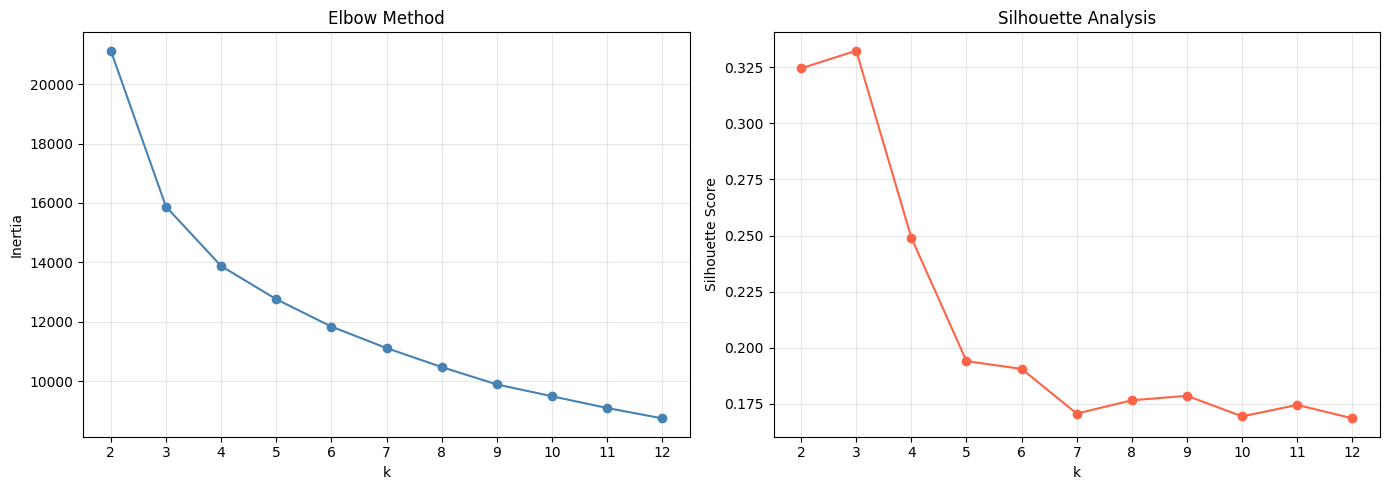

Silhouette scores by k:
  k=2: 0.324
  k=3: 0.332  <-- best by silhouette
  k=4: 0.249  <-- chosen to match main analysis
  k=5: 0.194
  k=6: 0.191
  k=7: 0.171
  k=8: 0.177
  k=9: 0.179
  k=10: 0.169
  k=11: 0.175
  k=12: 0.169


In [ ]:
k_range = range(2, 13)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))

best_k = list(k_range)[sil_scores.index(max(sil_scores))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), sil_scores, 'o-', color='tomato')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Silhouette scores by k:')
for k, score in zip(k_range, sil_scores):
    tag = ''
    if k == best_k:
        tag = '  <-- best by silhouette'
    if k == 4:
        tag += '  <-- chosen to match main analysis'
    print(f'  k={k}: {score:.3f}{tag}')

### 17.4 K-Means Clustering (Multi-Season)

The multi-season model uses **k = 4** to stay consistent with the single-season analysis. Even though k = 3 had the highest silhouette score in this section, k = 4 gives a clearer basketball interpretation and allows the same four archetype labels to be tracked over time.


In [ ]:
K = 4
ARCHETYPE_LABELS = {
    0: 'Elite Star',
    1: 'Paint Big',
    2: 'Bench / Limited Role Player',
    3: 'Perimeter Wing / 3-and-D',
}


In [ ]:
km = KMeans(n_clusters=K, random_state=42, n_init=20)
df_model['cluster']   = km.fit_predict(X)
df_model['archetype'] = df_model['cluster'].map(ARCHETYPE_LABELS)

colors = cm.tab10(np.linspace(0, 1, K))

print('Player-seasons per cluster:')
print(df_model['cluster'].value_counts().sort_index())
print('\nArchetype counts:')
print(df_model['archetype'].value_counts())
print('\nPosition breakdown per cluster:')
print(pd.crosstab(df_model['cluster'], df_model['pos']))

Player-seasons per cluster:
cluster
0    131
1    237
2    680
3    343
Name: count, dtype: int64

Archetype counts:
archetype
Bench / Limited Role Player    680
Perimeter Wing / 3-and-D       343
Paint Big                      237
Elite Star                     131
Name: count, dtype: int64

Position breakdown per cluster:
pos        C   PF   PG   SF   SG
cluster                         
0         24   33   45   14   15
1        171   51    1   13    1
2         32  144  115  176  213
3          4   45  102   71  121


In [ ]:
key_cols = ['pts_per_game', 'ast_per_game', 'drb_per_game', 'blk_per_game',
            'stl_per_game', 'x3p_per_game', 'ts_percent', 'per', 'bpm', 'vorp']
key_cols = [c for c in key_cols if c in df_model.columns]

print('Cluster Profiles (original-scale averages):')
display(df_model.groupby('archetype')[key_cols].mean().round(2))

Cluster Profiles (original-scale averages):


,pts_per_game,ast_per_game,drb_per_game,blk_per_game,stl_per_game,x3p_per_game,ts_percent,per,vorp
archetype,,,,,,,,,
Bench / Limited Role Player,8.34,1.92,2.50,0.34,0.71,1.28,0.56,11.51,0.12
Elite Star,24.79,6.14,5.86,0.71,1.19,2.05,0.60,22.87,4.04
Paint Big,10.51,1.69,4.85,0.95,0.66,0.48,0.62,17.84,1.07
Perimeter Wing / 3-and-D,16.57,4.15,3.64,0.40,0.98,2.05,0.57,15.61,1.23


### 17.5 KNN Similar Player Lookup (Multi-Season)

The KNN lookup identifies the closest player-seasons in the modeled feature space. This helps validate whether the model is grouping similar statistical profiles together. For example, star players should generally return other star seasons as their nearest neighbors.


In [ ]:
knn = NearestNeighbors(n_neighbors=6, metric='euclidean').fit(X)

def find_similar_players(player_name, season=None):
    """
    Return the 5 most similar player-seasons to the given player.
    If `season` is None, uses the player's most recent season in the dataset.
    """
    matches = df_model[df_model['player'] == player_name]
    if matches.empty:
        print(f'{player_name} not found in dataset.')
        return
    if season is not None:
        matches = matches[matches['season'] == season]
    idx = matches.index[-1]  # most recent (or specified) season
    dists, idxs = knn.kneighbors(X[idx].reshape(1, -1))
    neighbors = df_model.iloc[idxs[0][1:]][['player', 'season', 'team', 'archetype']].copy()
    neighbors['distance'] = dists[0][1:].round(3)
    print(f'Similar to {player_name} ({df_model.loc[idx, "season"]}):')
    display(neighbors.reset_index(drop=True))

find_similar_players('Nikola Jokić')
find_similar_players('Stephen Curry')
find_similar_players('Victor Wembanyama')

Similar to Nikola Jokić (2022):


,player,season,team,archetype,distance
0,Nikola Jokić,2024,DEN,Elite Star,1.254
1,Nikola Jokić,2025,DEN,Elite Star,2.068
2,Nikola Jokić,2023,DEN,Elite Star,2.185
3,Giannis Antetokounmpo,2024,MIL,Elite Star,4.014
4,Giannis Antetokounmpo,2022,MIL,Elite Star,4.560


Similar to Stephen Curry (2022):


,player,season,team,archetype,distance
0,Stephen Curry,2025,GSW,Elite Star,0.968
1,Donovan Mitchell,2023,CLE,Elite Star,1.509
2,Donovan Mitchell,2022,UTA,Elite Star,1.548
3,Anthony Edwards,2025,MIN,Elite Star,1.658
4,Donovan Mitchell,2024,CLE,Elite Star,1.801


Similar to Victor Wembanyama (2024):


,player,season,team,archetype,distance
0,Victor Wembanyama,2025,SAS,Elite Star,2.272
1,Jaren Jackson Jr.,2023,MEM,Paint Big,4.683
2,Anthony Davis,2025,2TM,Elite Star,4.879
3,Anthony Davis,2025,LAL,Elite Star,5.004
4,Anthony Davis,2022,LAL,Paint Big,5.122


### 17.6 Archetype Transition Matrix

The transition matrix shows what percentage of players in a given archetype in one season stayed in the same archetype in the next season or moved to another archetype.

A strong diagonal means the archetypes are stable over time. This is important because stable archetypes suggest the model is capturing real player roles rather than random yearly noise.


Unique players across all seasons: 508
Players in all 4 seasons:          152
Players in at least 2 seasons:     346


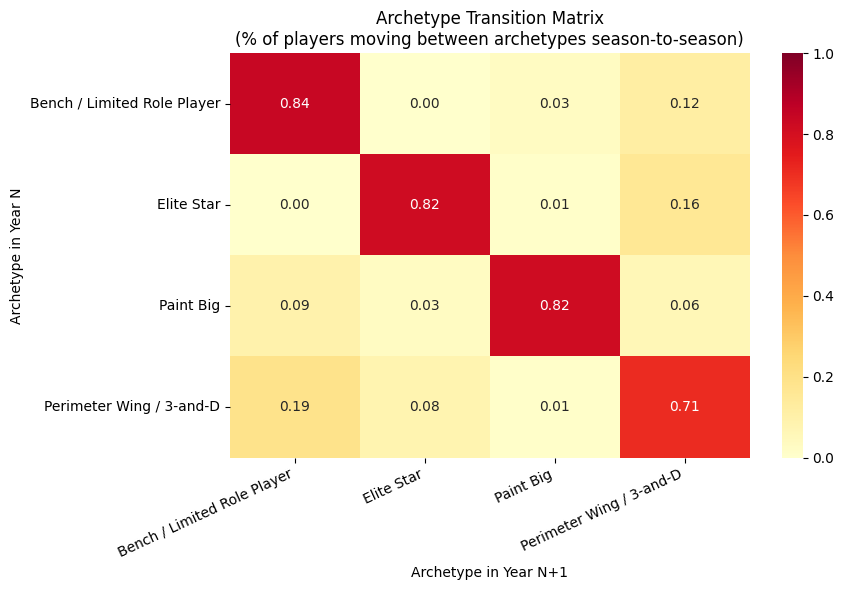

Average stay rate: 79.8%


In [ ]:
archetype_pivot = df_model.pivot_table(
    index='player', columns='season', values='archetype', aggfunc='first'
)
archetype_pivot.columns = [f'S{s}' for s in archetype_pivot.columns]
season_cols = archetype_pivot.columns.tolist()

print(f'Unique players across all seasons: {len(archetype_pivot)}')
print(f'Players in all 4 seasons:          {archetype_pivot.dropna().shape[0]}')
print(f'Players in at least 2 seasons:     {archetype_pivot.dropna(thresh=2).shape[0]}')


all_pairs = []
for i in range(len(season_cols) - 1):
    s_from, s_to = season_cols[i], season_cols[i + 1]
    pair = archetype_pivot[[s_from, s_to]].dropna()
    pair = pair.rename(columns={s_from: 'from', s_to: 'to'})
    all_pairs.append(pair)

transitions  = pd.concat(all_pairs)
trans_matrix = pd.crosstab(transitions['from'], transitions['to'], normalize='index').round(2)

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(trans_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Archetype Transition Matrix\n(% of players moving between archetypes season-to-season)')
ax.set_xlabel('Archetype in Year N+1')
ax.set_ylabel('Archetype in Year N')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

stay_rate = np.diag(trans_matrix.values).mean()
print(f'Average stay rate: {stay_rate:.1%}')

**Transition interpretation:** The multi-season transition matrix shows that many players remain in the same archetype across adjacent seasons. The average stay rate of about **79.8%** suggests the archetypes are reasonably stable over time, while still allowing for player development, role changes, injuries, and team-context changes.


### 17.7 Archetypes vs Traditional Positions

This comparison checks whether the data-driven archetypes match traditional NBA position labels. If the archetypes spread across several traditional positions, that suggests modern player roles are more flexible than the classic PG/SG/SF/PF/C system.


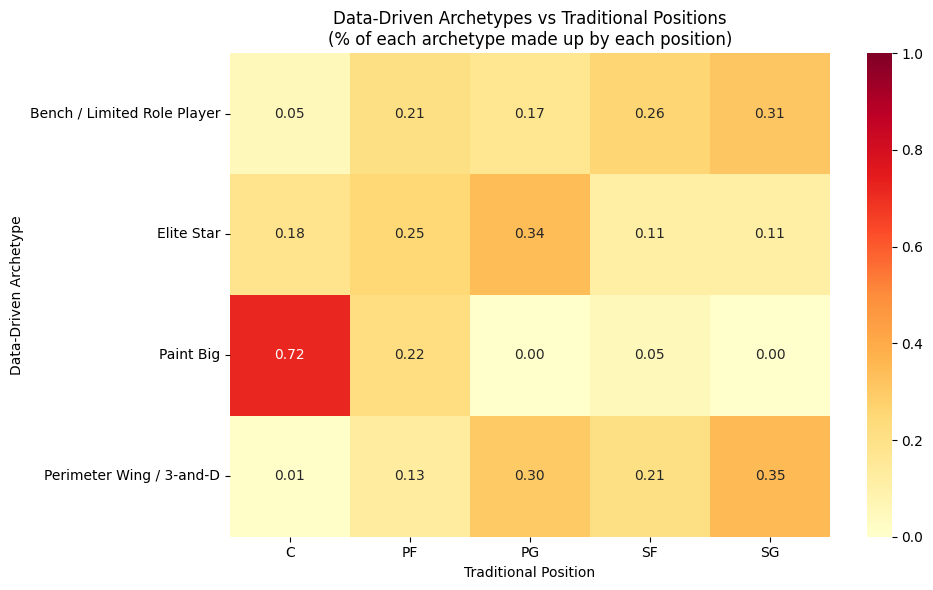

In [ ]:
position_cross = pd.crosstab(
    df_model['archetype'],
    df_model['pos'],
    normalize='index'
).round(2)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(position_cross, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Data-Driven Archetypes vs Traditional Positions\n'
             '(% of each archetype made up by each position)')
ax.set_xlabel('Traditional Position')
ax.set_ylabel('Data-Driven Archetype')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# Key finding:
# Only the Paint Big archetype aligns strongly with a traditional position (Centers).
# Perimeter Wing / 3-and-D and Elite Star spread across guards, wings, and forwards,
# demonstrating that traditional position labels carry little predictive value
# for player type in the modern NBA — except when identifying frontcourt bigs.

**Key finding:** Only the interior big archetype aligns strongly with a traditional position group. The star and perimeter archetypes spread across guards, wings, and forwards, which supports the main argument that traditional position labels do not fully describe modern NBA roles.


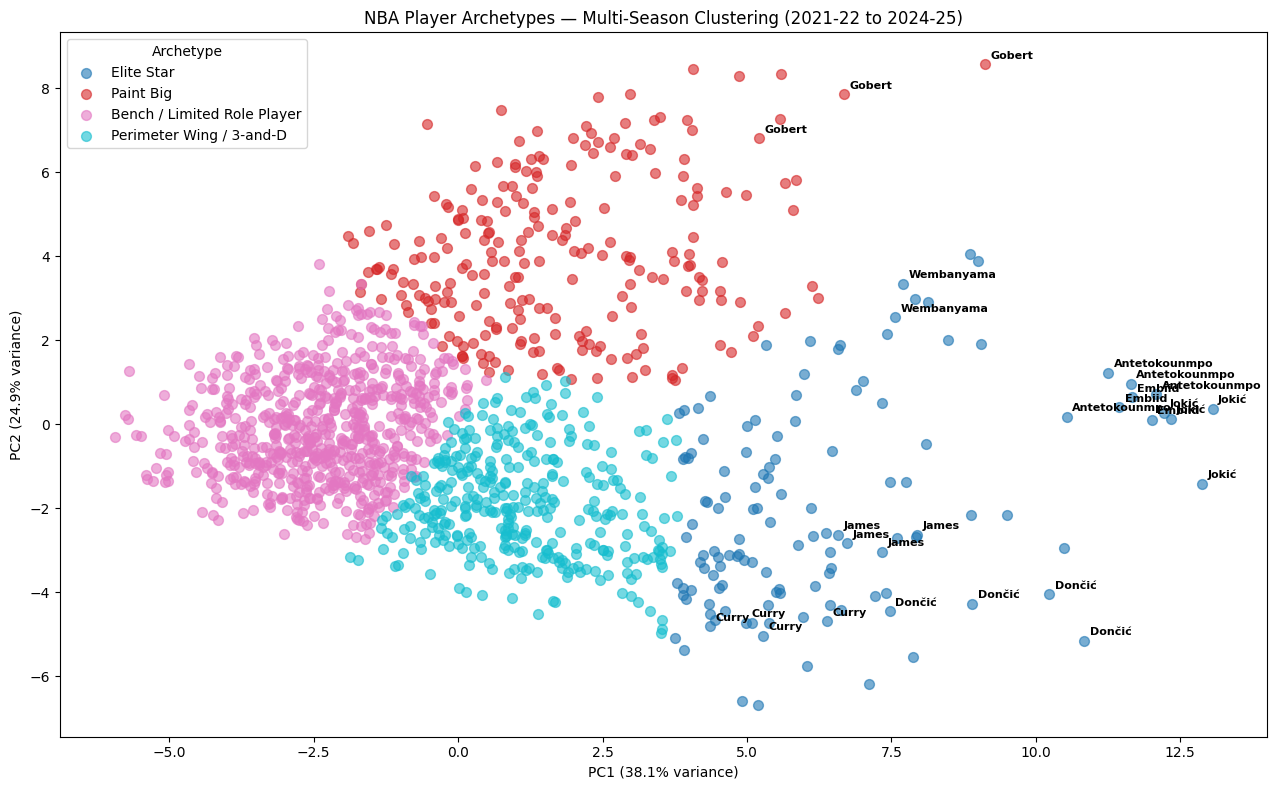

In [ ]:
pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(X_scaled)

# Store coordinates directly in df_model to avoid index alignment issues
df_model['pc1'] = X_viz[:, 0]
df_model['pc2'] = X_viz[:, 1]

notable = [
    'Nikola Jokić', 'LeBron James', 'Stephen Curry',
    'Victor Wembanyama', 'Giannis Antetokounmpo',
    'Rudy Gobert', 'Joel Embiid', 'Luka Dončić'
]

fig, ax = plt.subplots(figsize=(13, 8))

for c in sorted(df_model['cluster'].unique()):
    mask = df_model['cluster'] == c
    ax.scatter(
        df_model.loc[mask, 'pc1'],
        df_model.loc[mask, 'pc2'],
        color=colors[c],
        label=ARCHETYPE_LABELS[c],
        alpha=0.6,
        s=50
    )

for _, row in df_model[df_model['player'].isin(notable)].iterrows():
    ax.annotate(
        row['player'].split()[-1],
        (row['pc1'], row['pc2']),
        fontsize=8,
        xytext=(4, 4),
        textcoords='offset points',
        fontweight='bold'
    )

exp = pca_viz.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({exp[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({exp[1]*100:.1f}% variance)')
ax.set_title('NBA Player Archetypes — Multi-Season Clustering (2021-22 to 2024-25)')
ax.legend(title='Archetype', fontsize=10)
plt.tight_layout()
plt.show()